# Workshop: Gradient Descent in Single- and Multi-Layer Neural Networks

**Course:** Foundations of Machine Learning  
**Audience:** Entry-level students  
**Theme:** Understanding gradient descent mathematically, algorithmically, and through practice in **PyTorch**, followed by implementation challenges in **TensorFlow** and **Keras**.

## Learning goals
By the end of this workshop, students should be able to:

1. Explain gradient descent as an iterative optimization method for minimizing a loss function.
2. Interpret the gradient as the direction of steepest increase, and therefore understand why we move in the **negative gradient** direction.
3. Derive and apply gradient descent updates for a single-neuron model.
4. Describe how backpropagation enables gradient descent in multi-layer neural networks.
5. Use **PyTorch** to inspect gradients and train small neural networks.
6. Implement analogous training logic in **TensorFlow** and **Keras**.
7. Reflect on similarities and differences across the three frameworks.

## Suggested use
- Work through the notebook in order.
- Read each markdown explanation before running the code cell below it.
- Pause at the **challenge sections** and let students complete the missing pieces.



## 1. The big idea: what problem is gradient descent solving?

A neural network makes predictions using parameters such as **weights** and **biases**.  
To measure how wrong those predictions are, we define a **loss function**.

Examples:
- Regression: Mean Squared Error (MSE)
- Classification: Cross-Entropy Loss

Training is an optimization problem:

$$
\theta^* = \arg\min_{\theta} \mathcal{L}(\theta)
$$

where:
- $\theta$ represents all trainable parameters,
- $\mathcal{L}(\theta)$ is the loss.

Gradient descent updates the parameters iteratively:

$$
\theta_{t+1} = \theta_t - \eta \nabla_{\theta}\mathcal{L}(\theta_t)
$$

where:
- $\theta$ is the **learning rate**
- $\nabla_{\theta}\mathcal{L}(\theta_t)$ is the gradient of the loss with respect to the parameters at step \(t\)

### Why the negative gradient?
The gradient points in the direction of **steepest increase** of the loss.  
So, to reduce the loss as quickly as possible locally, we step in the **opposite** direction.

### Intuition
Think of standing on a hill in the fog:
- the **gradient** tells you which direction goes uphill fastest,
- so the **negative gradient** is your best immediate downhill step.



## 2. Warm-up math: a single-parameter example

Suppose the loss is

$$
L(w) = (w - 3)^2
$$

Then the derivative is

$$
\frac{dL}{dw} = 2(w - 3)
$$

Gradient descent update:

$$
w \leftarrow w - \eta \cdot 2(w - 3)
$$

If \(w=0\) and \(\eta=0.1\), then:

$$
\frac{dL}{dw} = 2(0-3) = -6
$$

$$
w_{\text{new}} = 0 - 0.1(-6) = 0.6
$$

Notice:
- the gradient is negative,
- subtracting a negative value increases \(w\),
- and that moves \(w\) toward the minimum at \(w=3\).


In [26]:

def simple_loss(w):
    return (w - 3.0) ** 2

def simple_grad(w):
    return 2.0 * (w - 3.0)

w = 0.0
learning_rate = 0.1

print(f"Initial w = {w:.4f}, loss = {simple_loss(w):.4f}")
for step in range(10):
    grad = simple_grad(w)
    w = w - learning_rate * grad
    print(f"step={step+1:2d} | grad={grad:8.4f} | w={w:8.4f} | loss={simple_loss(w):8.4f}")


Initial w = 0.0000, loss = 9.0000
step= 1 | grad= -6.0000 | w=  0.6000 | loss=  5.7600
step= 2 | grad= -4.8000 | w=  1.0800 | loss=  3.6864
step= 3 | grad= -3.8400 | w=  1.4640 | loss=  2.3593
step= 4 | grad= -3.0720 | w=  1.7712 | loss=  1.5099
step= 5 | grad= -2.4576 | w=  2.0170 | loss=  0.9664
step= 6 | grad= -1.9661 | w=  2.2136 | loss=  0.6185
step= 7 | grad= -1.5729 | w=  2.3709 | loss=  0.3958
step= 8 | grad= -1.2583 | w=  2.4967 | loss=  0.2533
step= 9 | grad= -1.0066 | w=  2.5973 | loss=  0.1621
step=10 | grad= -0.8053 | w=  2.6779 | loss=  0.1038



## 3. From one parameter to many parameters

In machine learning, we usually optimize multiple parameters:

$$
\theta = [w_1, w_2, \dots, w_n, b]
$$

The gradient becomes a vector:

$$
\nabla_{\theta}\mathcal{L} =
\left[
\frac{\partial \mathcal{L}}{\partial w_1},
\frac{\partial \mathcal{L}}{\partial w_2},
\dots,
\frac{\partial \mathcal{L}}{\partial w_n},
\frac{\partial \mathcal{L}}{\partial b}
\right]
$$

Each parameter gets its own update:

$$
w_i \leftarrow w_i - \eta \frac{\partial \mathcal{L}}{\partial w_i}
\qquad
b \leftarrow b - \eta \frac{\partial \mathcal{L}}{\partial b}
$$

This is exactly what happens in a neural network:
- perform a **forward pass**,
- compute the **loss**,
- compute gradients via **backpropagation**,
- update weights and biases.



## 4. Single neuron model: forward pass and gradient

Consider one neuron for regression:

$$
\hat{y} = wx + b
$$

For one data point, using squared error:

$$
L = (\hat{y} - y)^2 = (wx + b - y)^2
$$

### Gradients
Using the chain rule:

$$
\frac{\partial L}{\partial w} = 2(\hat{y} - y)x
$$

$$
\frac{\partial L}{\partial b} = 2(\hat{y} - y)
$$

### Update rules
$$
w \leftarrow w - \eta \cdot 2(\hat{y} - y)x
$$

$$
b \leftarrow b - \eta \cdot 2(\hat{y} - y)
$$

For a dataset, we often average the loss over many examples.


In [27]:
import numpy as np

# Tiny dataset for y = 2x + 1
x = np.array([0.0, 1.0, 2.0, 3.0])
y = np.array([1.0, 3.0, 5.0, 7.0])

w = 0.0
b = 0.0
learning_rate = 0.1
epochs = 20

for epoch in range(epochs):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)

    # Gradients for MSE
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    w -= learning_rate * dw
    b -= learning_rate * db

    print(f"epoch={epoch+1:2d} | loss={loss:8.4f} | w={w:7.4f} | b={b:7.4f}")


epoch= 1 | loss= 21.0000 | w= 1.7000 | b= 0.8000
epoch= 2 | loss=  0.5350 | w= 1.9700 | b= 0.9300
epoch= 3 | loss=  0.0143 | w= 2.0120 | b= 0.9530
epoch= 4 | loss=  0.0010 | w= 2.0177 | b= 0.9588
epoch= 5 | loss=  0.0006 | w= 2.0177 | b= 0.9617
epoch= 6 | loss=  0.0005 | w= 2.0168 | b= 0.9641
epoch= 7 | loss=  0.0005 | w= 2.0158 | b= 0.9662
epoch= 8 | loss=  0.0004 | w= 2.0149 | b= 0.9682
epoch= 9 | loss=  0.0004 | w= 2.0140 | b= 0.9701
epoch=10 | loss=  0.0003 | w= 2.0132 | b= 0.9719
epoch=11 | loss=  0.0003 | w= 2.0124 | b= 0.9736
epoch=12 | loss=  0.0003 | w= 2.0116 | b= 0.9752
epoch=13 | loss=  0.0002 | w= 2.0109 | b= 0.9766
epoch=14 | loss=  0.0002 | w= 2.0103 | b= 0.9780
epoch=15 | loss=  0.0002 | w= 2.0097 | b= 0.9793
epoch=16 | loss=  0.0002 | w= 2.0091 | b= 0.9806
epoch=17 | loss=  0.0001 | w= 2.0086 | b= 0.9817
epoch=18 | loss=  0.0001 | w= 2.0081 | b= 0.9828
epoch=19 | loss=  0.0001 | w= 2.0076 | b= 0.9838
epoch=20 | loss=  0.0001 | w= 2.0071 | b= 0.9848



## 5. Multi-layer networks and backpropagation

A deeper network composes functions. For example:

$$
z^{[1]} = W^{[1]}x + b^{[1]}
$$
$$
a^{[1]} = \sigma(z^{[1]})
$$
$$
z^{[2]} = W^{[2]}a^{[1]} + b^{[2]}
$$
$$
\hat{y} = a^{[2]}
$$

The loss depends on later layers, which depend on earlier layers.  
So to compute gradients for early weights, we use the **chain rule** repeatedly.

### Core idea of backpropagation
Backpropagation is just efficient repeated application of the chain rule.

For an early-layer weight $w$, the gradient looks like:

$$
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial \hat{y}}
\cdot
\frac{\partial \hat{y}}{\partial a^{[1]}}
\cdot
\frac{\partial a^{[1]}}{\partial z^{[1]}}
\cdot
\frac{\partial z^{[1]}}{\partial w}
$$

This is what automatic differentiation systems in modern frameworks compute for us.



## 6. Variants of gradient descent

### Batch Gradient Descent
Uses the full training set to compute the gradient.

\[
\theta \leftarrow \theta - \eta \nabla_{\theta}\mathcal{L}_{\text{full}}(\theta)
\]

- stable direction,
- expensive on large datasets.

### Stochastic Gradient Descent (SGD)
Uses one example at a time.

- cheap updates,
- noisy trajectory,
- often useful in practice.

### Mini-batch Gradient Descent
Uses a small batch, such as 32, 64, or 128 examples.

- standard choice in deep learning,
- balances efficiency and gradient quality.

In modern neural network training, when people say “gradient descent,” they often really mean **mini-batch SGD**.



## 7. Why learning rate matters

The learning rate \(\eta\) controls step size.

- Too small: training is very slow.
- Too large: the loss may oscillate or diverge.
- Reasonable value: steady progress toward a low-loss region.

A useful classroom question:
> Why is the gradient not enough by itself?

Because the gradient gives the **direction and local slope**, but the learning rate determines **how far** we move.


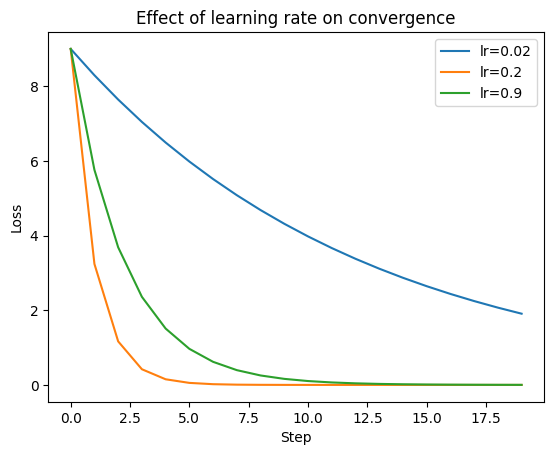

In [28]:

import matplotlib.pyplot as plt

def run_gd(lr, steps=20, w0=0.0):
    w = w0
    history = []
    for _ in range(steps):
        loss = (w - 3.0) ** 2
        grad = 2.0 * (w - 3.0)
        history.append((w, loss))
        w = w - lr * grad
    return np.array(history)

for lr in [0.02, 0.2, 0.9]:
    hist = run_gd(lr)
    plt.plot(hist[:, 1], label=f"lr={lr}")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Effect of learning rate on convergence")
plt.legend()
plt.show()



## 8. PyTorch part I: tensors, autograd, and a manual gradient step

PyTorch tracks operations on tensors when `requires_grad=True`.  
After a forward computation produces a scalar loss, calling `.backward()` computes gradients for all tracked parameters.

This is convenient because:
- we write the forward computation naturally,
- PyTorch builds the computational graph,
- autograd applies reverse-mode automatic differentiation.


In [29]:
import torch

torch.manual_seed(42)

# One parameter: w
w = torch.tensor([0.0], requires_grad=True)
target = torch.tensor([3.0])
learning_rate = 0.1

for step in range(10):
    loss = (w - target).pow(2).mean()
    loss.backward()

    with torch.no_grad():
        w -= learning_rate * w.grad

    print(f"step={step+1:2d} | w={w.item():.4f} | grad={w.grad.item():.4f} | loss={loss.item():.4f}")

    w.grad.zero_()


step= 1 | w=0.6000 | grad=-6.0000 | loss=9.0000
step= 2 | w=1.0800 | grad=-4.8000 | loss=5.7600
step= 3 | w=1.4640 | grad=-3.8400 | loss=3.6864
step= 4 | w=1.7712 | grad=-3.0720 | loss=2.3593
step= 5 | w=2.0170 | grad=-2.4576 | loss=1.5099
step= 6 | w=2.2136 | grad=-1.9661 | loss=0.9664
step= 7 | w=2.3709 | grad=-1.5729 | loss=0.6185
step= 8 | w=2.4967 | grad=-1.2583 | loss=0.3958
step= 9 | w=2.5973 | grad=-1.0066 | loss=0.2533
step=10 | w=2.6779 | grad=-0.8053 | loss=0.1621



### Discussion prompt
Why do we use `torch.no_grad()` during the parameter update?

Because the update itself is **not** part of the model's forward computation for the next loss evaluation.  
We want to change parameter values without asking PyTorch to differentiate through the update rule itself.



## 9. PyTorch part II: linear regression with gradient descent

We now fit a simple model:

$$
\hat{y} = wx + b
$$

using PyTorch tensors and autograd.


Learned w = 1.9855, b = 0.9474


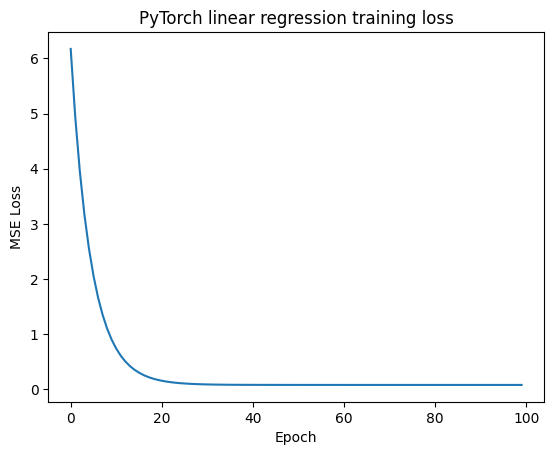

In [30]:

import torch
import matplotlib.pyplot as plt

torch.manual_seed(7)

# Synthetic data: y = 2x + 1 + noise
x = torch.linspace(-2, 2, 100).reshape(-1, 1)
noise = 0.3 * torch.randn_like(x)
y = 2 * x + 1 + noise

w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

learning_rate = 0.05
epochs = 100
loss_history = []

for epoch in range(epochs):
    y_hat = x * w + b
    loss = ((y_hat - y) ** 2).mean()
    loss.backward()

    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    w.grad.zero_()
    b.grad.zero_()

    loss_history.append(loss.item())

print(f"Learned w = {w.item():.4f}, b = {b.item():.4f}")

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("PyTorch linear regression training loss")
plt.show()



## 10. PyTorch part III: using `nn.Module` and `torch.optim.SGD`

This is closer to how real neural network training is usually written in PyTorch:
- define a model with `nn.Module`,
- define a loss function,
- choose an optimizer,
- run forward pass, backward pass, optimizer step.


In [31]:

import torch
import torch.nn as nn

torch.manual_seed(0)

x = torch.linspace(-2, 2, 100).reshape(-1, 1)
y = 2 * x + 1 + 0.3 * torch.randn_like(x)

model = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

loss_history = []

for epoch in range(100):
    preds = model(x)
    loss = criterion(preds, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

print("Learned parameters:")
for name, param in model.named_parameters():
    print(name, param.detach().numpy().ravel())


Learned parameters:
weight [1.9997989]
bias [1.0111167]


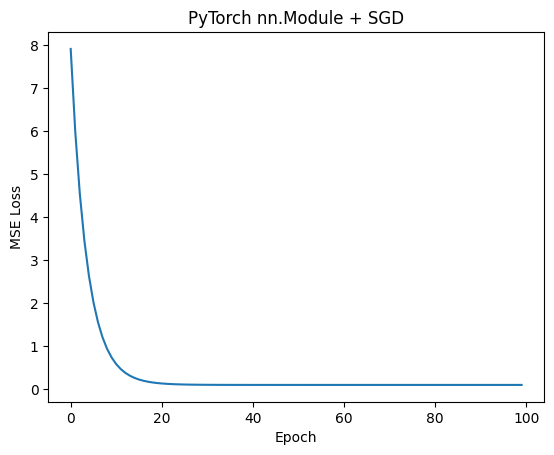

In [32]:

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("PyTorch nn.Module + SGD")
plt.show()



## 11. PyTorch part IV: a small multi-layer network

Now we move from a single linear neuron to a small multi-layer perceptron (MLP).  
This lets students see that the same gradient descent logic still works, but the gradient computation is handled through backpropagation automatically.


In [33]:

import torch
import torch.nn as nn

torch.manual_seed(123)

# Nonlinear regression dataset
x = torch.linspace(-3, 3, 200).reshape(-1, 1)
y = torch.sin(x) + 0.1 * torch.randn_like(x)

model = nn.Sequential(
    nn.Linear(1, 16),
    nn.Tanh(),
    nn.Linear(16, 16),
    nn.Tanh(),
    nn.Linear(16, 1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.03)

loss_history = []

for epoch in range(300):
    preds = model(x)
    loss = criterion(preds, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

print(f"Final loss: {loss_history[-1]:.4f}")


Final loss: 0.0401


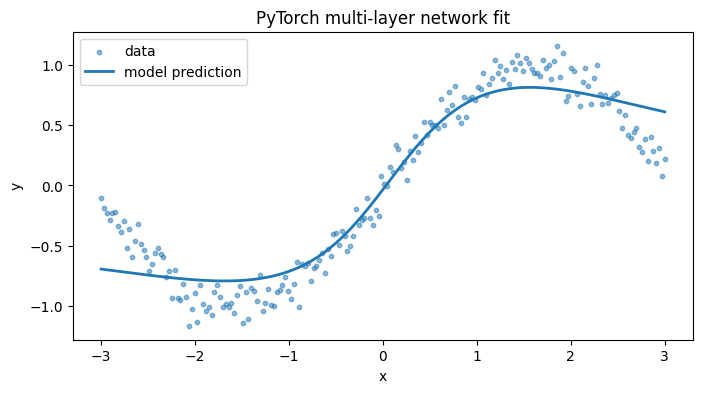

In [34]:

with torch.no_grad():
    preds = model(x)

plt.figure(figsize=(8, 4))
plt.scatter(x.numpy(), y.numpy(), s=10, alpha=0.5, label="data")
plt.plot(x.numpy(), preds.numpy(), linewidth=2, label="model prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("PyTorch multi-layer network fit")
plt.legend()
plt.show()



## 12. Inspecting gradients in PyTorch

One useful teaching move is to explicitly inspect gradients after `backward()`.


In [35]:

torch.manual_seed(1)

model = nn.Sequential(
    nn.Linear(1, 4),
    nn.ReLU(),
    nn.Linear(4, 1)
)

x_small = torch.tensor([[1.0], [2.0], [3.0]])
y_small = torch.tensor([[2.0], [4.0], [6.0]])

criterion = nn.MSELoss()

preds = model(x_small)
loss = criterion(preds, y_small)
loss.backward()

for name, param in model.named_parameters():
    print(f"{name:20s} | grad shape: {tuple(param.grad.shape)}")
    print(param.grad)
    print("-" * 60)


0.weight             | grad shape: (4, 1)
tensor([[-1.1462],
        [ 0.0736],
        [ 0.0000],
        [-0.4364]])
------------------------------------------------------------
0.bias               | grad shape: (4,)
tensor([-0.4404,  0.0736,  0.0000, -0.1859])
------------------------------------------------------------
2.weight             | grad shape: (1, 4)
tensor([[ -2.5321,  -0.1903,   0.0000, -12.1389]])
------------------------------------------------------------
2.bias               | grad shape: (1,)
tensor([-7.5377])
------------------------------------------------------------



## 13. Algorithm summary

### Generic gradient descent
1. Initialize parameters.
2. Repeat until stopping condition:
   1. Run forward pass.
   2. Compute loss.
   3. Compute gradients of loss with respect to parameters.
   4. Update parameters in the negative gradient direction.

### In neural networks
1. Forward pass through all layers.
2. Loss computation.
3. Backpropagation.
4. Parameter update.
5. Repeat over many epochs.

### Common stopping conditions
- fixed number of epochs,
- validation loss stops improving,
- gradients become very small,
- training budget is exhausted.



## 14. Student challenge A — implement gradient descent manually in PyTorch

Complete the TODOs below.

**Goal:** Train a single-parameter model \( \hat{y} = wx \) on a tiny dataset using a manual gradient descent loop with autograd.


In [40]:

# CHALLENGE A: Manual gradient descent in PyTorch
# Students: fill in the TODOs.

import torch

torch.manual_seed(666)

# Prepare data: x is input, y is target (y = 2x)
x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y = torch.tensor([[2.0], [4.0], [6.0], [8.0]])

#Initialize weight w and enable gradient tracking
w = torch.randn(1, 1, requires_grad=True)
learning_rate = 0.01

for epoch in range(200):
    # TODO 1: compute predictions:using matrix multiplication
    y_hat = x @ w

    # TODO 2: Compute Mean Squared Error (MSE) loss
    loss = ((y_hat - y) ** 2).mean()

    # TODO 3: Backpropagate to compute gradients of loss with respect to w
    loss.backward()

    # TODO 4: update the parameter inside a no_grad block
    with torch.no_grad():
        # Move in the direction opposite to the gradient
        w -= learning_rate * w.grad

    # TODO 5: reset gradients:prevent them from accumulating in the next iteration
    w.grad.zero_()

print("Learned weight:", w.detach().numpy())
print("Final loss:", loss.item())


Learned weight: [[1.9999996]]
Final loss: 8.988365607365267e-13


### 
* Learned weight  `[[1.9999996]]`   
    In data, $y$ is always 2 times $x$. The model found the weight to be 1.9999996, which is almost exactly 2. This means model successfully discovered the correct relationship.
* Final loss `8.988365607365267e-13`    
    Don't be scared by the long number! Look at the e-13 at the end. This means the number is very small ($0.0000...$).Loss means "error."Because this number is very close to zero, it means model’s predictions are nearly perfect.



## 15. Student challenge B — TensorFlow implementation with `tf.GradientTape`

In TensorFlow, the analogous idea is to:
- open a `GradientTape`,
- compute the forward pass and loss inside the tape,
- ask the tape for gradients,
- update variables.

Students should connect the mathematical update rule to the framework-specific API.


In [37]:

# CHALLENGE B: Implement gradient descent in TensorFlow
# Uncomment and complete if TensorFlow is installed in your environment.

# import tensorflow as tf
#
# tf.random.set_seed(0)
#
# x = tf.constant([[1.0], [2.0], [3.0], [4.0]])
# y = tf.constant([[3.0], [5.0], [7.0], [9.0]])   # target: y = 2x + 1
#
# W = tf.Variable(tf.random.normal((1, 1)))
# b = tf.Variable(tf.zeros((1,)))
# learning_rate = 0.01
#
# for epoch in range(300):
#     with tf.GradientTape() as tape:
#         # TODO 1: forward pass
#         y_hat = tf.matmul(x, W) + b
#
#         # TODO 2: mean squared error
#         loss = tf.reduce_mean(tf.square(y_hat - y))
#
#     # TODO 3: compute gradients with respect to W and b
#     dW, db = tape.gradient(loss, [W, b])
#
#     # TODO 4: update parameters
#     W.assign_sub(learning_rate * dW)
#     b.assign_sub(learning_rate * db)
#
#     if epoch % 50 == 0:
#         print(f"epoch={epoch}, loss={loss.numpy():.4f}")
#
# print("Learned W:", W.numpy())
# print("Learned b:", b.numpy())



### TensorFlow extension challenge
Modify the TensorFlow code so that:
1. the data contains random noise,
2. training runs with mini-batches using `tf.data.Dataset`,
3. you store the loss after every epoch and plot it.

**Questions**
- Does noise make convergence less smooth?
- How does mini-batch training change the behavior of the optimization path?



## 16. Student challenge C — Keras implementation

Keras is the higher-level interface in the TensorFlow ecosystem.  
Students can first use `model.compile(...)` and `model.fit(...)`, then move to a custom training step if desired.

### Part 1: high-level Keras API


In [38]:

# CHALLENGE C1: Keras high-level training
# Uncomment and run if TensorFlow/Keras is installed.

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
#
# tf.random.set_seed(0)
#
# x = tf.constant([[1.0], [2.0], [3.0], [4.0]])
# y = tf.constant([[3.0], [5.0], [7.0], [9.0]])
#
# model = keras.Sequential([
#     layers.Dense(1, input_shape=(1,))
# ])
#
# # TODO 1: compile the model with SGD and MSE
# model.compile(
#     optimizer=keras.optimizers.SGD(learning_rate=0.01),
#     loss="mse"
# )
#
# # TODO 2: fit the model
# history = model.fit(x, y, epochs=200, verbose=0)
#
# print("Final loss:", history.history["loss"][-1])
# print("Weights:", model.get_weights())



### Part 2: Keras custom training loop

This version helps students see that Keras can also be used in a lower-level style similar to raw TensorFlow training loops.


In [39]:

# CHALLENGE C2: Keras custom training loop
# Uncomment and run if TensorFlow/Keras is installed.

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
#
# tf.random.set_seed(0)
#
# x = tf.constant([[1.0], [2.0], [3.0], [4.0]])
# y = tf.constant([[3.0], [5.0], [7.0], [9.0]])
#
# model = keras.Sequential([
#     layers.Input(shape=(1,)),
#     layers.Dense(8, activation="relu"),
#     layers.Dense(1)
# ])
#
# optimizer = keras.optimizers.SGD(learning_rate=0.01)
# loss_fn = keras.losses.MeanSquaredError()
#
# for epoch in range(200):
#     with tf.GradientTape() as tape:
#         # TODO 1: forward pass
#         preds = model(x, training=True)
#
#         # TODO 2: compute loss
#         loss = loss_fn(y, preds)
#
#     # TODO 3: compute gradients
#     grads = tape.gradient(loss, model.trainable_weights)
#
#     # TODO 4: apply gradients
#     optimizer.apply_gradients(zip(grads, model.trainable_weights))
#
#     if epoch % 50 == 0:
#         print(f"epoch={epoch}, loss={loss.numpy():.4f}")
#
# print("Final weights:")
# for w in model.trainable_weights:
#     print(w.name, w.numpy().shape)



## 17. Reflection challenge

Discuss the following in small groups, then write short answers.

### A. Conceptual understanding
1. Why does the gradient indicate the direction of steepest increase?
2. Why do we subtract the gradient instead of adding it?
3. What role does the learning rate play?
4. Why is gradient descent iterative instead of one-step?
5. Why do multi-layer networks require backpropagation?

### B. Practical understanding
6. What happens when gradients are very small?
7. What happens when the learning rate is too large?
8. Why is mini-batch training so common in deep learning?
9. Why do we reset gradients in PyTorch before the next iteration?

### C. Framework comparison
10. In PyTorch, how do `loss.backward()` and `optimizer.step()` divide the work?
11. In TensorFlow, what is the role of `tf.GradientTape()`?
12. In Keras, what do you gain from `model.fit(...)`, and what do you lose compared with a custom training loop?
13. Which framework felt most transparent for learning? Which felt most convenient?

### D. Synthesis
14. Explain gradient descent to a first-year student without using equations.
15. Explain gradient descent to a mathematically mature student using the idea of local linear approximation.



## 18. Instructor talking points / sample insights

These can support debrief discussion after the exercises.

### Key insight 1
Gradient descent does not “magically know” the best weights.  
It uses **local slope information** to make repeated improvements.

### Key insight 2
Backpropagation is not a separate learning rule from gradient descent.  
It is the efficient method used to compute the gradients that gradient descent needs.

### Key insight 3
Single-layer and multi-layer networks share the same optimization principle:
- compute loss,
- compute gradients,
- update parameters.

The difference is that deeper networks require more chain-rule structure.

### Key insight 4
PyTorch, TensorFlow, and Keras implement the same core idea with different user experiences:
- **PyTorch:** usually the most transparent for teaching and debugging.
- **TensorFlow:** explicit and flexible with `GradientTape`.
- **Keras:** highest-level and fastest to prototype, but can hide some mechanics unless custom loops are used.

### Key insight 5
Framework differences are mostly about **API design**, not about changing the mathematics.



## 19. Optional extension activities

1. Replace MSE with binary cross-entropy for a simple binary classification task.
2. Compare SGD with Adam on the same dataset.
3. Vary the batch size and observe the loss curve.
4. Change the activation function from `Tanh` to `ReLU`.
5. Introduce a validation set and discuss overfitting versus optimization.
6. Ask students to implement one full epoch of mini-batch gradient descent from scratch using NumPy only.



## 20. Summary

Gradient descent is the optimization engine behind neural network training.

At a high level:
- define a loss,
- measure how predictions are wrong,
- compute gradients of that loss with respect to parameters,
- move the parameters in the negative gradient direction.

In practice:
- **PyTorch** uses autograd and explicit training loops,
- **TensorFlow** uses `tf.GradientTape`,
- **Keras** offers both high-level training and lower-level custom loops.

Different framework, same mathematics.



## 21. Sources and suggested references

This workshop draws on the following trustworthy sources for conceptual framing and framework-specific mechanics:

1. **PyTorch Tutorials** — *A Gentle Introduction to torch.autograd*  
   https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html

2. **PyTorch Tutorials** — *Neural Networks*  
   https://docs.pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html

3. **TensorFlow Core Guide** — *Introduction to gradients and automatic differentiation*  
   https://www.tensorflow.org/guide/autodiff

4. **TensorFlow Core Guide** — *Writing a training loop from scratch*  
   https://www.tensorflow.org/guide/keras/writing_a_training_loop_from_scratch

5. **Stanford CS231n** — *Lecture 3: Regularization and Optimization*  
   https://cs231n.stanford.edu/slides/2025/lecture_3.pdf

### Notes for students
- Official documentation is the best place to confirm API details.
- CS231n is especially useful for optimization intuition and visual explanations.
- For classroom use, encourage students to translate between equations and code.



## 22. Environment note

The PyTorch cells in this notebook should run in a standard Python environment with:
- `torch`
- `numpy`
- `matplotlib`

The TensorFlow and Keras challenge cells are included as commented starter code so the notebook remains easy to open even if TensorFlow is not installed.  
To run those sections, install TensorFlow in your environment and uncomment the relevant cells.


## 🧩 Workshop Structure (120 Minutes)

1. **Instructor-led walkthrough of Vector Space Proximity** *(20 min)*  
   - Form teams of 3  
   - Review the notebook structure and expectations  
   - Understand the Gradient Descent algorithm  
   - Ask questions before starting implementation  

2. **Team Jupyter Notebook Development** *(90 min)*  
   - Complete **all four challenges**:
     - Challenge A: Implement Gradient Descent in PyTorch  
     - Challenge B: Implement Gradient Descent in TensorFlow
     - Challenge C: Implement Gradient Descent in Keras
     - Reflection Challenge
   - Document all steps using Markdown and inline comments

3. **Push to GitHub** *(5 min)*  
   - One team member pushes the final notebook  
   - ⚠️ Include all team member names clearly in the notebook  

4. **Produce a PDF document with:**  
   - Your names and student IDs
   - The title of the workshop  
   - **GitHub repo link (*.git)**  

5. **Dropbox Submission** *(5 min)*  
   - One submission per team  
   - Drop the PDF document


## 💻 Submission Checklist

- ✅ `GradientDescent_Workshop.ipynb` with:

  - Demo code for all three challenges:
    - Documentation with **inline comments**

  - Talking points:
    - Section A: Conceptual Understanding
    - Section B: Practical Understanding
    - Section C: Framework Comparison
    - Section D: Synthesis

---

- ✅ `README.md` with:

  - Workshop description  
  - Team member names  
  - Summary of the work completed

---

- ✅ GitHub Repository:

  - Public repo named:  
    `GradientDescent_Workshop`  

  - One team member publishes the repo  

  - At least **one meaningful commit** that includes:
    - The original workshop file cloned from the instructor's Git, with completed challenges  
    - An updated README file
    - A requirements.txt file for replicability

---

### 🧠 Key Requirement

Your workshop submission must demonstrate that:

> **You have studied and understood your answers, even the AI-generated material.**
